In [1]:
import pymssql
import pandas as pd
import numpy as np
import time
import sqlalchemy
import sqlite3
from itertools import count
import pysal
import esda
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
import libpysal as lps
import numpy as np
import matplotlib.pyplot as plt
# from pysal.mapclassify import K
from seaborn.palettes import color_palette
from shapely.geometry import Point
import openpyxl
from esda.getisord import G_Local
import datetime as dt



/opt/homebrew/Caskroom/miniforge/base/envs/ACLED_Analytics/lib/python3.9/site-packages/pysal/explore/segregation/network/network.py:15: UserWarning: You need pandana and urbanaccess to work with segregation's network module
You can install them with  `pip install urbanaccess pandana` or `conda install -c udst pandana urbanaccess`
  warn(
/opt/homebrew/Caskroom/miniforge/base/envs/ACLED_Analytics/lib/python3.9/site-packages/pysal/model/spvcm/abstracts.py:10: UserWarning: The `dill` module is required to use the sqlite backend fully.
  from .sqlite import head_to_sql, start_sql


In [2]:
# Couldn't get pyodbc to work on new machine, so I'm using pymssql instead
conn = pymssql.connect(server = '10.200.8.20',
                      database = 'UNDP_DW_CRD',
                      user = 'sqlUNDPCRDReader',
                      password = '',
                      port=1433)
        

query = "SELECT * FROM CRD_ACLED WHERE [CountryFK] = 3 AND [ACLED_Year] = 2021"
data = pd.read_sql(query, conn)

In [3]:
conflict = data

In [4]:
#Set for identical results
np.random.seed(2021)
#Import Relevant Country Shapefile
poly = gpd.read_file('./adm3/lka_admbnda_adm3_slsd_20200305.shp')

In [5]:
data

,ACLED_PK,KPIFK,TimeFK_Event_Date,CountryFK,ACLED_Region,ACLED_GWNO,ACLED_Event_ID_Cnty,ACLED_Event_ID_No_Cnty,ACLED_Year,ACLED_Time_Precision,...,ACLED_Longitude,ACLED_Geo_Precision,ACLED_Source,ACLED_SourceScale,ACLED_Notes,ACLED_Fatalities,ACLED_CreatedOn,ACLED_CreatedBy,ACLED_UpdatedOn,ACLED_UpdatedBy
0,11445506,95,20210902,3,South Asia,None,SRI5083,5083,2021,1,...,80.4296,1,Virakesari; Thinakkural; Colombo Post,National,"On 2 September 2021, police personnel assaulte...",0,2021-09-08 01:10:24.340,RES01\svcDW_Admin_UNDP,NaT,None
1,11435722,95,20210806,3,South Asia,None,SRI5119,5119,2021,1,...,79.9533,1,Hiru News,National,"On 6 August 2021, a group of parents in suppor...",0,2021-09-08 01:10:24.340,RES01\svcDW_Admin_UNDP,NaT,None
2,11508599,95,20211120,3,South Asia,None,SRI5352,5352,2021,1,...,79.8784,1,Hiru News,National,"Weapons seizure: On 20 November 2021, police r...",0,2021-12-01 02:10:10.720,RES01\svcDW_Admin_UNDP,NaT,None
3,11441383,95,20210821,3,South Asia,None,SRI5077,5077,2021,1,...,81.7334,2,Virakesari,National,"Defusal: On 21 August 2021, police recovered a...",0,2021-09-08 01:10:24.340,RES01\svcDW_Admin_UNDP,NaT,None
4,11398282,95,20210630,3,South Asia,None,SRI4904,4904,2021,2,...,79.7327,1,Sunday Times (Sri Lanka),National,"Around 30 June 2021 (as reported), a group of ...",0,2021-07-07 01:27:03.970,RES01\svcDW_Admin_UNDP,NaT,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909,11446711,95,20210516,3,South Asia,None,SRI4804,4804,2021,1,...,79.9249,1,Colombo Gazette,National,"On 16 May 2021, unidentified assailants assaul...",0,2021-09-11 07:34:22.330,RES01\svcDW_Admin_UNDP,2021-12-11 10:17:34.330,RES01\svcDW_Admin_UNDP
910,11450494,95,20210905,3,South Asia,None,SRI5136,5136,2021,1,...,81.6924,1,Lanka Views; Tamil Guardian,National-International,"On 5 September 2021, police personnel assaulte...",0,2021-09-15 01:10:27.460,RES01\svcDW_Admin_UNDP,NaT,None
911,11450061,95,20210902,3,South Asia,None,SRI5135,5135,2021,1,...,81.8538,1,Tamil Guardian,International,"On 2 September 2021, police personnel blindfol...",0,2021-09-15 01:10:27.460,RES01\svcDW_Admin_UNDP,NaT,None
912,11391496,95,20210613,3,South Asia,None,SRI4838,4838,2021,1,...,80.4971,1,Thinakkural,National,"On 13 June 2021, a group of assailants attacke...",0,2021-06-30 01:29:31.720,RES01\svcDW_Admin_UNDP,NaT,None


In [6]:
# Filt data 
def convert_dt(value):
    valstr = str(value)
    date_clean = dt.datetime(year=int(valstr[0:4]), month=int(valstr[4:6]), day=int(valstr[6:8]))
    return date_clean

conflict['TimeFK_Event_Date'] = conflict['TimeFK_Event_Date'].apply(lambda x: convert_dt(x))

conflict = conflict[(conflict['TimeFK_Event_Date'] > '20210801') & (conflict['TimeFK_Event_Date'] < '20211231')]

In [8]:
#Define geometry of events data
geometry = [Point(xy)  for xy in zip(conflict['ACLED_Longitude'], conflict['ACLED_Latitude'])]
crs = 'epsg:4326'

#Build spatial data frame
conflict_geo = GeoDataFrame(conflict, crs=crs, geometry=geometry)

#Create merged spatial data frame to confirm matching dimensions
sj_gdf = gpd.sjoin(poly, conflict_geo, how='inner', op='intersects', lsuffix='left', rsuffix='right')

list(sj_gdf)

/opt/homebrew/Caskroom/miniforge/base/envs/ACLED_Analytics/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3377: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):


['ADM3_EN',
 'ADM3_SI',
 'ADM3_TA',
 'ADM3_PCODE',
 'ADM3_REF',
 'ADM3ALT1EN',
 'ADM3ALT2EN',
 'ADM3ALT1SI',
 'ADM3ALT2SI',
 'ADM3ALT1TA',
 'ADM3ALT2TA',
 'ADM2_EN',
 'ADM2_SI',
 'ADM2_TA',
 'ADM2_PCODE',
 'ADM1_EN',
 'ADM1_SI',
 'ADM1_TA',
 'ADM1_PCODE',
 'ADM0_EN',
 'ADM0_SI',
 'ADM0_TA',
 'ADM0_PCODE',
 'Shape_Leng',
 'Shape_Area',
 'date',
 'validOn',
 'validTo',
 'geometry',
 'index_right',
 'ACLED_PK',
 'KPIFK',
 'TimeFK_Event_Date',
 'CountryFK',
 'ACLED_Region',
 'ACLED_GWNO',
 'ACLED_Event_ID_Cnty',
 'ACLED_Event_ID_No_Cnty',
 'ACLED_Year',
 'ACLED_Time_Precision',
 'ACLED_Event_Type',
 'ACLED_Event_TypeDesc',
 'ACLED_Event_SubType',
 'ACLED_Event_SubTypeDesc',
 'ACLED_Actor1',
 'ACLED_Ally_Actor1',
 'ACLED_Inter1',
 'ACLED_Actor2',
 'ACLED_Ally_Actor2',
 'ACLED_Inter2',
 'ACLED_Interaction',
 'ACLED_Admin1',
 'ACLED_Admin2',
 'ACLED_Admin3',
 'ACLED_Location',
 'ACLED_Latitude',
 'ACLED_Longitude',
 'ACLED_Geo_Precision',
 'ACLED_Source',
 'ACLED_SourceScale',
 'ACLED_Notes',

In [10]:
#############
# Generrate counts variables
#############
#Fatalities
Total_f_gdf = sj_gdf['ACLED_Fatalities'].groupby([sj_gdf['ADM3_EN']]).sum()

#Total Events
Total_e_gdf = sj_gdf['ADM3_EN'].groupby([sj_gdf['ADM3_EN']]).count()
Total_e_gdf.rename('Event Count', inplace=True)

####Create event type df
#protests
prot = sj_gdf.loc[sj_gdf['ACLED_Event_Type'] == "Protests"].groupby(['ADM3_EN']).agg({'ACLED_Event_Type':'count'}).squeeze()
prot.rename('Protest Count', inplace=True)


#######Actor Type - Did not do this yet (mainly as ACLED['Actor_Type'].value_counts() in the sri lanka case was not promising) - maybe look into interaction

####Concatenate dataframes
merged_df = pd.concat([Total_e_gdf, Total_f_gdf, prot],axis=1)

In [33]:
#Merge with geospatial dataframe
fin_gdf = poly.join(merged_df, on='ADM3_EN')
#fin_gdf = fin_gdf.join(Total_e_gdf, on='NA')

#Assumption here for ACLED is that if there is no event of that type in a polygon then none have happened
# fin_gdf.fillna({'Protest Count':0, 'Riot Count':0, 'VOC Count':0, 'StratDev Count':0, 
#                 'Explosive/Remote Violence Count':0, 'Battles Count':0, 'Event Count':0, 
#                 'ACLED_Fatalities':0}, inplace=True)

fin_gdf.fillna({'Protest Count':0, 'Event Count':0, 
                'ACLED_Fatalities':0}, inplace=True)

#Alternatively could fill nas by means (doesn't make sense to me) - have to do this for spatial z-score calculation to work as nans throw the calculation
# fin_gdf.fillna({'Protest Count':fin_gdf['Protest Count'].mean(), 'Riot Count':fin_gdf['Riot Count'].mean(), 'VOC Count':fin_gdf['Protest Count'].mean(), 'StratDev Count':fin_gdf['Protest Count'].mean(), 
#                 'Explosive/Remote Violence Count':fin_gdf['Protest Count'].mean(), 'Battles Count':fin_gdf['Protest Count'].mean(), 'Event Count':fin_gdf['Protest Count'].mean(), 
#                 'ACLED_Fatalities':fin_gdf['Protest Count'].mean()}, inplace=True)



In [17]:
fin_gdf.ADM2_EN

0          Jaffna
1      Batticaloa
2       [unknown]
3          Ampara
4        Kalutara
          ...    
328        Matale
329         Galle
330        Matale
331         Kandy
332       Kegalle
Name: ADM2_EN, Length: 333, dtype: object

In [24]:
####
#Weights (Google Contiguity and Spatial Associaton for more info - also pysal's documentation and user example was used heavily for this script)
####
#Queen contiguity
# wq = lps.weights.Queen.from_shapefile(filepath='adm3/lka_admbnda_adm3_slsd_20200305.shp')
# wq.transform = 'b'

#KNN
wk= lps.weights.KNN.from_shapefile(filepath='adm3/lka_admbnda_adm3_slsd_20200305.shp', k=5)
# wk.transform='r'

/opt/homebrew/Caskroom/miniforge/base/envs/ACLED_Analytics/lib/python3.9/site-packages/libpysal/weights/weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 50.
  warnings.warn(message)


In [30]:
fin_gdf.tail()

,ADM3_EN,ADM3_SI,ADM3_TA,ADM3_PCODE,ADM3_REF,ADM3ALT1EN,ADM3ALT2EN,ADM3ALT1SI,ADM3ALT2SI,ADM3ALT1TA,...,geometry,Event Count,ACLED_Fatalities,Protest Count,Protest Count_Gzs,Protest Count_Gpsim,Event Count_Gzs,Event Count_Gpsim,ACLED_Fatalities_Gzs,ACLED_Fatalities_Gpsim
328,Wilgamuwa,විල්ගමුව,வில்கமுவை,LK2227,None,None,None,None,None,None,...,"POLYGON ((80.98656 7.71951, 80.98671 7.71788, ...",0.0,0.0,0.0,0.130474,0.163,0.130474,0.166,0.130474,0.168
329,Yakkalamulla,යක්කලමුල්ල,யக்கலமுல்லை,LK3148,None,None,None,None,None,None,...,"POLYGON ((80.37493 6.16593, 80.37497 6.16590, ...",0.0,0.0,0.0,-0.268652,0.126,-0.268652,0.111,-0.268652,0.115
330,Yatawatta,යටවත්ත,யட்டவத்தை,LK2215,None,None,None,None,None,None,...,"MULTIPOLYGON (((80.58302 7.60023, 80.58334 7.6...",0.0,0.0,0.0,-0.211634,0.281,-0.211634,0.282,-0.211634,0.253
331,Yatinuwara,යටිනුවර,யட்டிநுவரை,LK2136,None,None,None,None,None,None,...,"POLYGON ((80.56603 7.31922, 80.56609 7.31922, ...",0.0,0.0,0.0,-0.211634,0.281,-0.211634,0.282,-0.211634,0.253
332,Yatiyantota,යටියන්තොට,எட்டியாந்தோட்டை,LK9227,None,None,None,None,None,None,...,"MULTIPOLYGON (((80.41031 7.08112, 80.41093 7.0...",0.0,0.0,0.0,-0.325670,0.001,-0.325670,0.001,-0.325670,0.001


In [56]:
#Set varlist
# continued
varlist = ['Protest Count', 'Event Count', 'ACLED_Fatalities']

#invalid value in battles var - check acled data source - UPDATE solved - due to no battles happenng 2020 it's just a divide by zero - results for 2020 null
#Calculate G* z-scores
#For contigutiy (queen wieghts) set transform parameter to 'R' (source: Arcgis documentation)
for var in varlist:
    print(var)
    #df = fin_gdf.copy()
    #df[var].dropna(inplace=True)
    # G = G_Local(fin_gdf[var], wq, star=True, permutations=999)
    G = G_Local(fin_gdf['Event Count'], wk, transform='r', permutations=999)
    fin_gdf[var+'_Gzs'] = G.Zs
    fin_gdf[var+'_Gpsim'] = G.p_sim

Protest Count
Event Count
ACLED_Fatalities


In [44]:
fin_gdf

,ADM3_EN,ADM3_SI,ADM3_TA,ADM3_PCODE,ADM3_REF,ADM3ALT1EN,ADM3ALT2EN,ADM3ALT1SI,ADM3ALT2SI,ADM3ALT1TA,...,geometry,Event Count,ACLED_Fatalities,Protest Count,Protest Count_Gzs,Protest Count_Gpsim,Event Count_Gzs,Event Count_Gpsim,ACLED_Fatalities_Gzs,ACLED_Fatalities_Gpsim
0,[unknown],[unknown],[unknown],LK4100,None,None,None,None,None,None,...,"POLYGON ((80.25377 9.62172, 80.25399 9.62223, ...",0.0,0.0,0.0,0.220425,0.156,0.220425,0.152,0.220425,0.161
1,[unknown],[unknown],[unknown],LK5100,None,None,None,None,None,None,...,"MULTIPOLYGON (((81.64758 7.50611, 81.64766 7.5...",0.0,0.0,0.0,0.698733,0.052,0.698733,0.051,0.698733,0.056
2,[unknown],[unknown],[unknown],LK6000,None,None,None,None,None,None,...,"POLYGON ((79.80303 7.85030, 79.80333 7.84946, ...",0.0,0.0,0.0,-0.326213,0.001,-0.326213,0.001,-0.326213,0.001
3,Addalaichenai,අඩ්ඩාලච්චේන,அட்டாளைச்சேனை,LK5233,None,None,None,None,None,None,...,"POLYGON ((81.85587 7.30252, 81.85600 7.30250, ...",1.0,0.0,1.0,-0.120175,0.444,-0.120175,0.445,-0.120175,0.446
4,Agalawatta,අගලවත්ත,அகலவத்தை,LK1333,None,None,None,None,None,None,...,"POLYGON ((80.18547 6.58111, 80.18556 6.58106, ...",0.0,0.0,0.0,-0.326213,0.001,-0.326213,0.001,-0.326213,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,Wilgamuwa,විල්ගමුව,வில்கமுவை,LK2227,None,None,None,None,None,None,...,"POLYGON ((80.98656 7.71951, 80.98671 7.71788, ...",0.0,0.0,0.0,0.220425,0.169,0.220425,0.147,0.220425,0.170
329,Yakkalamulla,යක්කලමුල්ල,யக்கலமுல்லை,LK3148,None,None,None,None,None,None,...,"POLYGON ((80.37493 6.16593, 80.37497 6.16590, ...",0.0,0.0,0.0,-0.257883,0.123,-0.257883,0.139,-0.257883,0.121
330,Yatawatta,යටවත්ත,யட்டவத்தை,LK2215,None,None,None,None,None,None,...,"MULTIPOLYGON (((80.58302 7.60023, 80.58334 7.6...",0.0,0.0,0.0,-0.189553,0.273,-0.189553,0.290,-0.189553,0.271
331,Yatinuwara,යටිනුවර,யட்டிநுவரை,LK2136,None,None,None,None,None,None,...,"POLYGON ((80.56603 7.31922, 80.56609 7.31922, ...",0.0,0.0,0.0,-0.189553,0.273,-0.189553,0.290,-0.189553,0.271


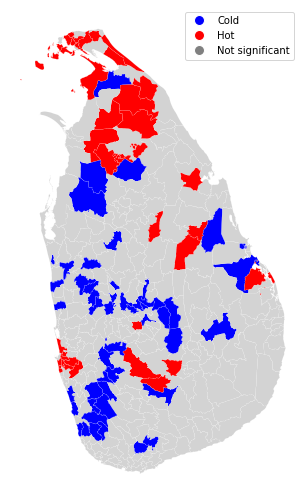

In [57]:
#viz - in case one wants to check results / or play with confidence levels before deploying
import matplotlib.pyplot as plt
from descartes import PolygonPatch
BLUE = '#6699cc'
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import cm
#Viz results - #G_psim is the pvalue threshold (e.g. .10 = 90% confidence interval)
## Genearte maps in map directory
df = fin_gdf.copy()
conditions = [
    (df['Event Count_Gpsim'] < 0.10) & (df['Event Count_Gzs'] > 0),
    (df['Event Count_Gpsim'] < 0.10) & (df['Event Count_Gzs'] < 0),
    (df['Event Count_Gpsim'] > 0.10)
     ]

#Can ignore this - is just for visualizing with ggplot/python but I am sure there's a better way to do it with tableau
#Essentially created dummy variables based on significance level to then visualize
choices = [1,2,0]

df['viz'] = np.select(conditions, choices)

legend_elements = [   Line2D([0], [0], marker='o', color='w', label='Cold',
                          markerfacecolor='Blue', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Hot',
                          markerfacecolor='Red', markersize=10),
                    Line2D([0], [0], marker='o', color='w', label='Not significant',
                          markerfacecolor='Grey', markersize=10)]


#Static map here
from matplotlib import colors
hmap = colors.ListedColormap([ 'lightgrey', 'red', 'blue'])
f, ax = plt.subplots(1, figsize=(9, 9))
df.assign(cl=df['viz']).plot(column='cl', categorical=True, \
        k=2, cmap=hmap, linewidth=0.1, ax=ax, \
        edgecolor='white')
ax.legend(handles=legend_elements, loc='upper right')        
ax.set_axis_off()
#plt.title("Protest Hot and Cold Zones (ACLED 2020-2021)")
plt.show()